In [1]:
import sys

project_path = '/content/drive/MyDrive/credit_score_project'

if project_path not in sys.path:
    sys.path.append(project_path)

In [2]:
import kagglehub
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import my_module.custom_transformers as cst
from datetime import datetime
sklearn.set_config(transform_output = 'pandas')

In [ ]:
gmsc_dataset_raw =pd.read_csv('/content/drive/MyDrive/credit_score_project/datasets_cleaned/gmsc_cleaned.csv',index_col='Unnamed: 0')
gmsc_df = gmsc_dataset_raw.copy()

In [ ]:
gmsc_df

,defaults,RUUL,age,30-59 passed,DebtRatio,MonthlyIncome,open credits,90 passed,Real Estate credits,60-89 passed,dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [ ]:
target_col = 'defaults'
X = gmsc_df.drop(columns=target_col)
y = gmsc_df[target_col]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42,stratify=y)

print(y_train.sum()/y_train.shape[0])
print(y_test.sum()/y_test.shape[0])

0.06659809719722294
0.06657981349424026


In [ ]:
X_train

,RUUL,age,30-59 passed,DebtRatio,MonthlyIncome,open credits,90 passed,Real Estate credits,60-89 passed,dependents
74292,0.343349,49,0,0.424672,6484.0,14,0,1,0,2.0
36261,0.000000,37,2,0.549542,1200.0,4,0,1,0,2.0
128511,0.738946,38,1,0.098697,3606.0,6,3,0,1,1.0
115589,0.965451,36,1,0.298672,7000.0,5,0,0,0,4.0
98092,0.053483,80,0,0.110217,4100.0,6,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...
36050,0.873250,30,0,0.503749,6000.0,9,0,1,0,0.0
105368,0.008757,66,0,0.222725,15700.0,8,0,2,0,0.0
95217,0.666656,75,1,0.498978,4400.0,16,0,1,0,0.0
136805,0.517985,43,0,0.382784,9200.0,8,0,2,0,2.0


In [ ]:
gmsc_preprocess = joblib.load('/content/drive/MyDrive/credit_score_project/preprocessing/gmsc_preprocess_v1.joblib')

from sklearn.pipeline import check_is_fitted
try:
  check_is_fitted(csc_preprocess)
except:
  print("not fitted")


not fitted


In [ ]:
X_train_preprocessed = gmsc_preprocess.fit_transform(X_train)
X_test_preprocessed = gmsc_preprocess.transform(X_test)
X_train_preprocessed.head()


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


,MonthlyIncome,DebtRatio,RUUL,open credits,Real Estate credits,90 passed,30-59 passed,60-89 passed,age,MonthlyIncome_missing
74292,0.273931,-0.422398,0.061496,1.064291,-0.027314,-0.187931,-0.353632,-0.197504,-0.214252,0
36261,-1.111562,-0.379262,-0.916738,-0.885077,-0.027314,-0.187931,2.500329,-0.197504,-1.037381,0
128511,-0.208031,-0.555791,1.188587,-0.495203,-0.918961,6.019847,1.073348,2.848877,-0.968787,0
115589,0.336834,-0.469940,1.833921,-0.690140,-0.918961,-0.187931,1.073348,-0.197504,-1.105975,0
98092,-0.102575,-0.550436,-0.764359,-0.495203,-0.027314,-0.187931,-0.353632,-0.197504,1.912163,0


Now after the prepocessing pipeline is completed we can go ahead and use the
pipleline for different models. First step is to make a base LR classifier and
discuss all the matric that we will be using for evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
gmsc_base_lr = LogisticRegression()
gmsc_base_lr.fit(X_train_preprocessed,y_train)
y_pred = gmsc_base_lr.predict(X_test_preprocessed)

In [ ]:
y_pred[:100]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    log_loss,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    classification_report
)

from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

def save_results_to_excel(
    metrics_df,
    dataset_name,
    model_name,
    params,
    comments=None,
    file_path="model_results.xlsx"
):

    # -----------------------------
    # Convert metrics to single row
    # -----------------------------
    metrics_row = metrics_df.T.reset_index(drop=True)

    # -----------------------------
    # Metadata
    # -----------------------------
    meta = pd.DataFrame([{
        "dataset_name": dataset_name,
        "model_name": model_name,
        "params": str(params),
        "comments": comments,
        "timestamp": datetime.now()
    }])

    # -----------------------------
    # Combine everything
    # -----------------------------
    final_row = pd.concat([meta, metrics_row], axis=1)

    # -----------------------------
    # Save / append to Excel
    # -----------------------------
    if os.path.exists(file_path):
        existing = pd.read_excel(file_path)
        final_row = pd.concat([existing, final_row], ignore_index=True)

    final_row.to_excel(file_path, index=False)

    print(f"Results saved to {file_path}")


def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=0.5,
    feature_names=None,
    n_repeats=20
):

    results = {}
    results["class_weight_train"] = f"{y_train.value_counts(normalize=True)}"
    results["class_weight_test"] = f"{y_test.value_counts(normalize=True)}"
    # -----------------------------
    # Predictions
    # -----------------------------
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    train_pred = (train_proba >= threshold).astype(int)
    test_pred = (test_proba >= threshold).astype(int)

    # -----------------------------
    # Discrimination Metrics
    # -----------------------------
    auc_train = roc_auc_score(y_train, train_proba)
    auc_test = roc_auc_score(y_test, test_proba)

    results["ROC_AUC_train"] = auc_train
    results["ROC_AUC_test"] = auc_test

    results["Gini"] = 2 * auc_test - 1

    precision, recall, _ = precision_recall_curve(y_test, test_proba)
    pr_auc = auc(recall, precision)
    results["PR_AUC"] = pr_auc

    fpr, tpr, thresholds = roc_curve(y_test, test_proba)
    ks = max(tpr - fpr)
    results["KS"] = ks

    # -----------------------------
    # Probability Metrics
    # -----------------------------
    results["LogLoss"] = log_loss(y_test, test_proba)
    results["BrierScore"] = brier_score_loss(y_test, test_proba)

    # -----------------------------
    # Threshold Metrics
    # -----------------------------
    results["Accuracy"] = accuracy_score(y_test, test_pred)
    results["Precision"] = precision_score(y_test, test_pred)
    results["Recall"] = recall_score(y_test, test_pred)
    results["F1"] = f1_score(y_test, test_pred)

    results["classification_report"] = f"{classification_report(y_test, test_pred)}"

    # -----------------------------
    # Generalization
    # -----------------------------
    train_error = 1 - accuracy_score(y_train, train_pred)
    test_error = 1 - accuracy_score(y_test, test_pred)

    results["Train_Error"] = train_error
    results["Test_Error"] = test_error
    results["Overfit_Gap_AUC"] = auc_train - auc_test

    results_df = pd.DataFrame(results, index=["Model_Evaluation"]).T

    # =============================
    # Feature Importance
    # =============================
    perm = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=n_repeats,
        scoring="roc_auc",
        random_state=42
    )

    if feature_names is None:
        feature_names = X_test.columns

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    # =============================
    # PLOTS
    # =============================
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # ROC Curve
    axes[0,0].plot(fpr, tpr)
    axes[0,0].plot([0,1],[0,1],'--')
    axes[0,0].set_title(f"ROC Curve (AUC={auc_test:.3f})")
    axes[0,0].set_xlabel("False Positive Rate")
    axes[0,0].set_ylabel("True Positive Rate")

    # Precision Recall Curve
    axes[0,1].plot(recall, precision)
    axes[0,1].set_title(f"PR Curve (PR-AUC={pr_auc:.3f})")
    axes[0,1].set_xlabel("Recall")
    axes[0,1].set_ylabel("Precision")

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=axes[1,0])
    axes[1,0].set_title("Confusion Matrix")

    # Calibration Curve
    prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10)

    axes[1,1].plot(prob_pred, prob_true, marker="o")
    axes[1,1].plot([0,1],[0,1],'--')
    axes[1,1].set_title("Calibration Curve")
    axes[1,1].set_xlabel("Predicted Probability")
    axes[1,1].set_ylabel("Actual Probability")

    plt.tight_layout()
    plt.show()

    # Feature Importance Plot
    plt.figure(figsize=(8,6))
    plt.barh(importance_df["feature"], importance_df["importance_mean"])
    plt.gca().invert_yaxis()
    plt.title("Permutation Feature Importance")
    plt.xlabel("Decrease in ROC-AUC")
    plt.show()

    return results_df, importance_df

# Does the model rank risk well?
# Does the model identify defaulters?
# Are probabilities reliable?
# Does model generalize?
# What drives predictions?

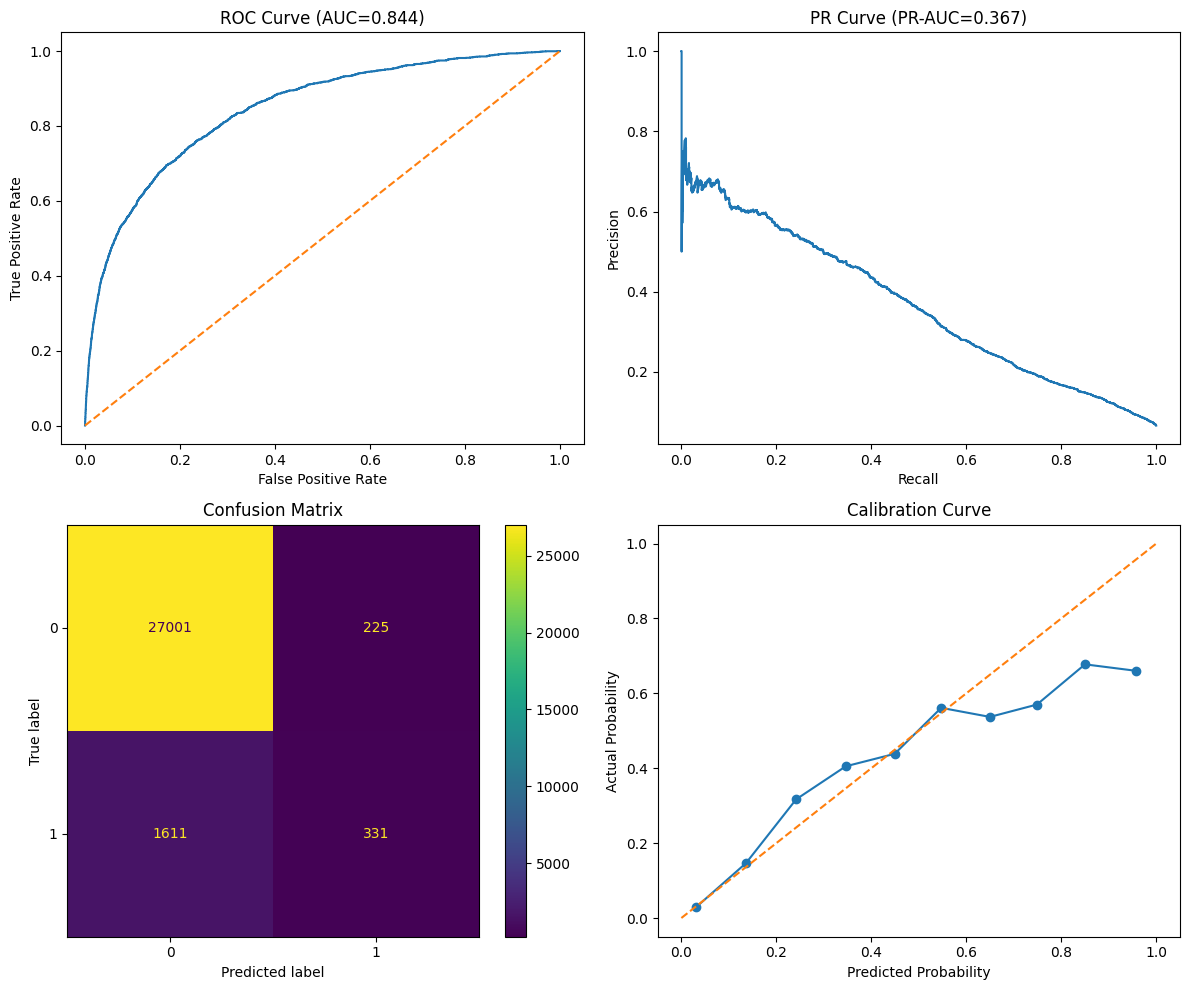

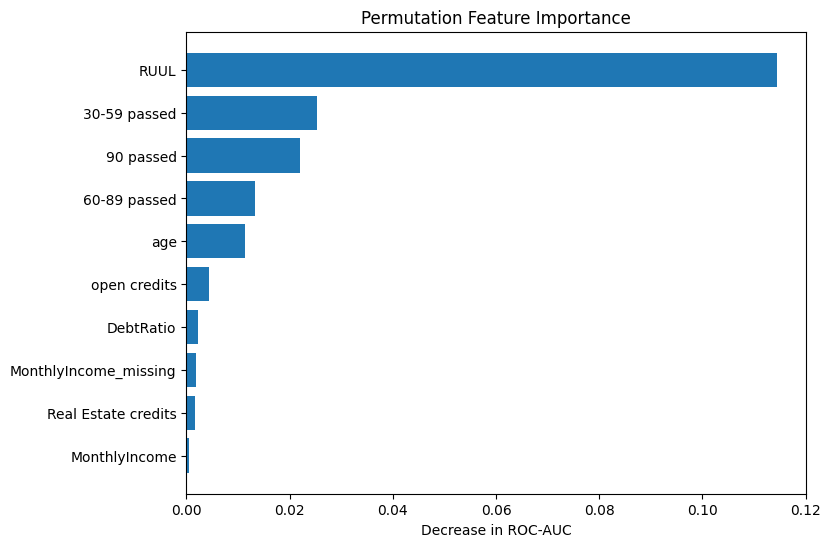

In [ ]:
metrics, feature_importance= evaluate_model(
    model=gmsc_base_lr,
    X_train=X_train_preprocessed,
    y_train=y_train,
    X_test=X_test_preprocessed,
    y_test=y_test
)

In [ ]:
metrics

,Model_Evaluation
class_weight_train,defaults\n0 0.933402\n1 0.066598\nName: ...
class_weight_test,defaults\n0 0.93342\n1 0.06658\nName: pr...
ROC_AUC_train,0.849235
ROC_AUC_test,0.843761
Gini,0.687522
PR_AUC,0.366842
KS,0.526015
LogLoss,0.188945
BrierScore,0.051117
Accuracy,0.937054


In [ ]:
# save_results_to_excel(
#     metrics_df=metrics,
#     dataset_name="GMSC",
#     model_name="Base_Logistic_Regression",
#     params=gmsc_base_lr.get_params(),
#     comments="baseline model",
#     file_path = '/content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx'
# )

In [ ]:
df_train = pd.concat([X_train_preprocessed,y_train],axis=1)
df_train

,MonthlyIncome,DebtRatio,RUUL,open credits,Real Estate credits,90 passed,30-59 passed,60-89 passed,age,MonthlyIncome_missing,defaults
74292,0.273931,-0.422398,0.061496,1.064291,-0.027314,-0.187931,-0.353632,-0.197504,-0.214252,0,0
36261,-1.111562,-0.379262,-0.916738,-0.885077,-0.027314,-0.187931,2.500329,-0.197504,-1.037381,0,0
128511,-0.208031,-0.555791,1.188587,-0.495203,-0.918961,6.019847,1.073348,2.848877,-0.968787,0,0
115589,0.336834,-0.469940,1.833921,-0.690140,-0.918961,-0.187931,1.073348,-0.197504,-1.105975,0,0
98092,-0.102575,-0.550436,-0.764359,-0.495203,-0.027314,-0.187931,-0.353632,-0.197504,1.912163,0,0
...,...,...,...,...,...,...,...,...,...,...,...
36050,0.210203,-0.394664,1.571232,0.089607,-0.027314,-0.187931,-0.353632,-0.197504,-1.517539,0,1
105368,1.000416,-0.500878,-0.891787,-0.105330,0.864332,-0.187931,-0.353632,-0.197504,0.951846,0,0
95217,-0.044570,-0.396295,0.982626,1.454165,-0.027314,-0.187931,1.073348,-0.197504,1.569193,0,0
136805,0.561343,-0.437719,0.559050,-0.105330,0.864332,-0.187931,-0.353632,-0.197504,-0.625817,0,0


In [ ]:
df_train.columns
num_cols = ['MonthlyIncome', 'DebtRatio', 'RUUL', 'open credits',
       'Real Estate credits', '90 passed', '30-59 passed', '60-89 passed',
       'age']
cat_cols = ['MonthlyIncome_missing']
target_col = ['defaults']

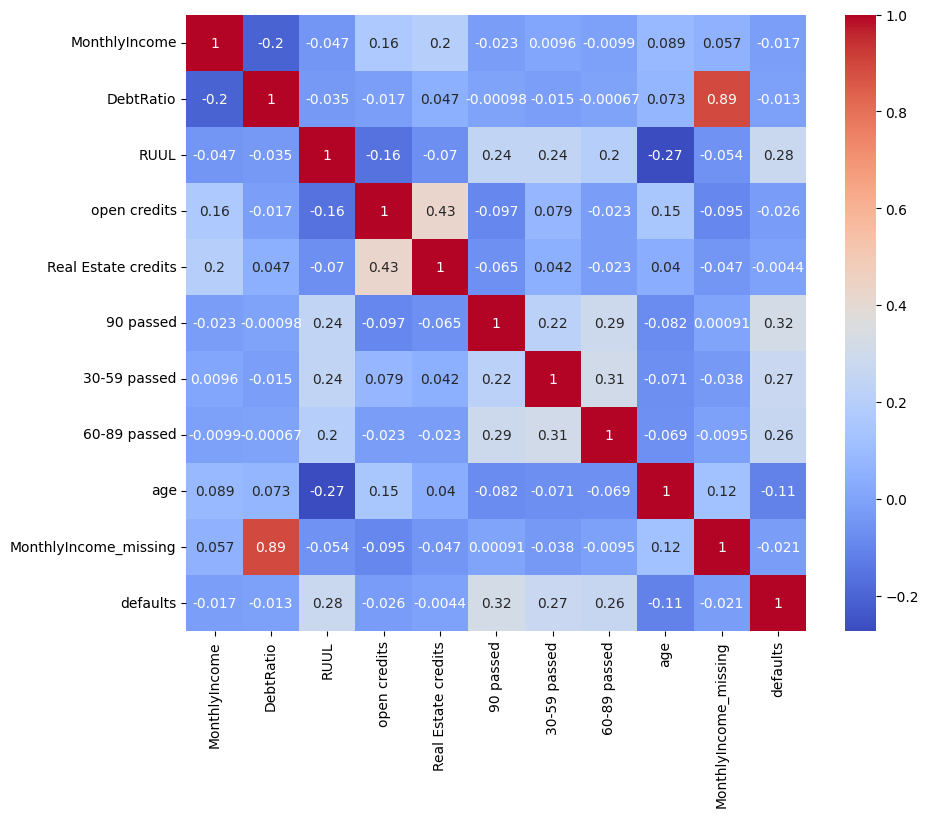

In [ ]:
corr_matrix = df_train.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap = 'coolwarm')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_train[num_cols]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data.sort_values(by="VIF", ascending=False)

,Feature,VIF
3,open credits,1.296066
4,Real Estate credits,1.264505
2,RUUL,1.214958
6,30-59 passed,1.182368
7,60-89 passed,1.180275
5,90 passed,1.155813
8,age,1.110182
0,MonthlyIncome,1.108239
1,DebtRatio,1.062868


In [ ]:
import pandas as pd
from scipy.stats import ttest_ind
results = []

for col in num_cols:

  group0 = df_train.loc[df_train['defaults']==0, col].dropna()
  group1 = df_train.loc[df_train['defaults']==1, col].dropna()

  t_stat, p_val = ttest_ind(group0, group1, equal_var=False)

  results.append({
            "feature": col,
            "t_statistic": t_stat,
            "p_value": p_val,
            "Flag": p_val<0.05
    })

  results_df = pd.DataFrame(results)
results_df

# Here p_value < 0.05 means H0(variance may differ) can't be rejected.

,feature,t_statistic,p_value,Flag
0,MonthlyIncome,6.838066,8.520218e-12,True
1,DebtRatio,4.747148,2.094487e-06,True
2,RUUL,-93.087661,0.000000e+00,True
3,open credits,8.097551,6.365364e-16,True
4,Real Estate credits,1.187632,2.350119e-01,False
5,90 passed,-42.404671,0.000000e+00,True
6,30-59 passed,-49.495889,0.000000e+00,True
7,60-89 passed,-38.322669,8.335284e-295,True
8,age,43.371164,0.000000e+00,True


In [ ]:
from scipy.stats import chi2_contingency
results = []
for col in cat_cols:
    contingency_table = pd.crosstab(df_train[col], df_train[target_col[0]])

    chi, p, dof, expected = chi2_contingency(contingency_table)
    results.append({
        "feature":col,
        "chi":chi ,
        "p_value":p,
        "Flag": p < 0.05,
        "dof":dof,
        "expected":expected
    })
chi_results = pd.DataFrame(results)
chi_results

,feature,chi,p_value,Flag,dof,expected
0,MonthlyIncome_missing,50.354115,1.283606e-12,True,1,"[[89686.85523270763, 6399.144767292363], [1921..."


In [ ]:
chi_columns = list (chi_results[chi_results['Flag']==False].feature)
for col in chi_columns:
  print(df_train[col].value_counts())

real estate credit can be removed based on the results but as no of Features are low for now not removing it. Later we can make revisit this decisions after the feature importance from different tunned model and can make decisions if required.

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


base_models = {
    "Logistic Regression": LogisticRegression(),

    # "SVM": SVC(kernel='linear',probability=True),

    # "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "XGBoost": XGBClassifier()
}

Training Logistic Regression


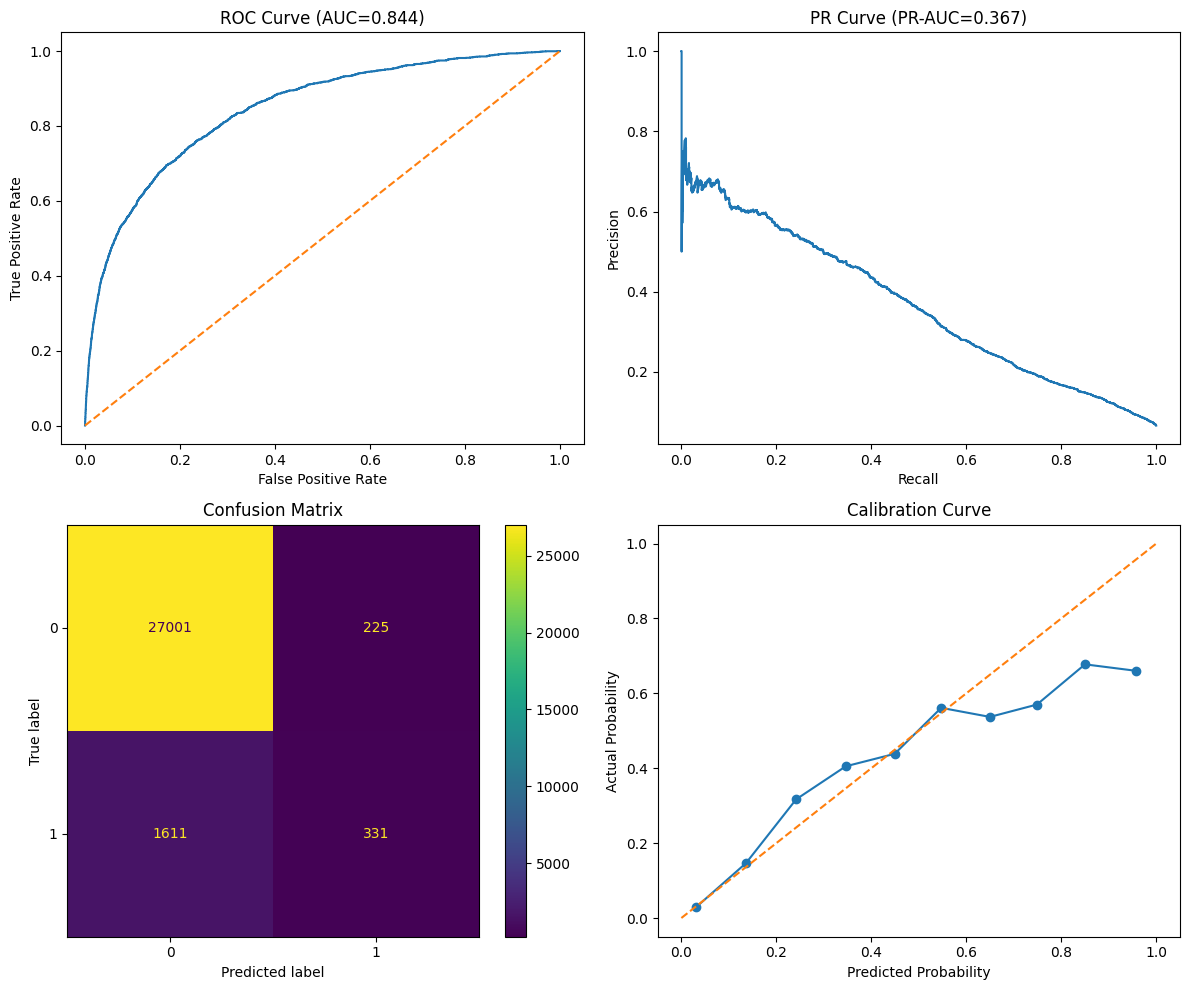

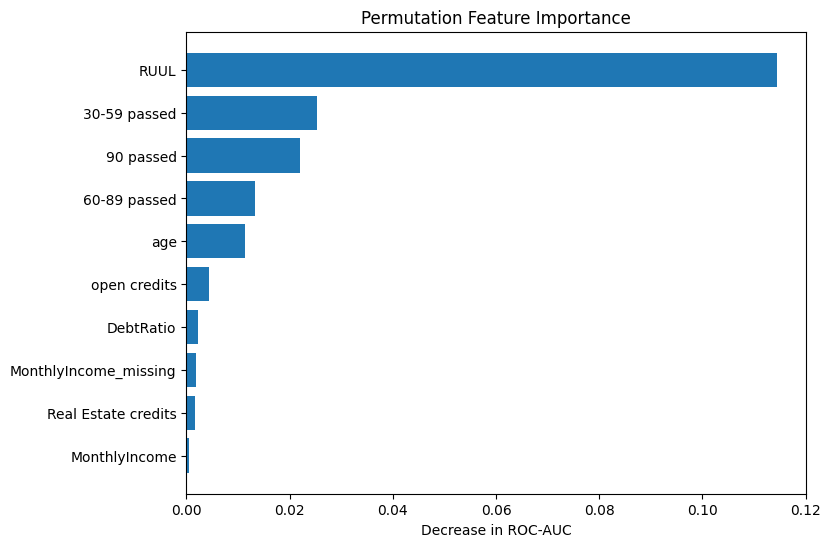

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx
Training Decision Tree


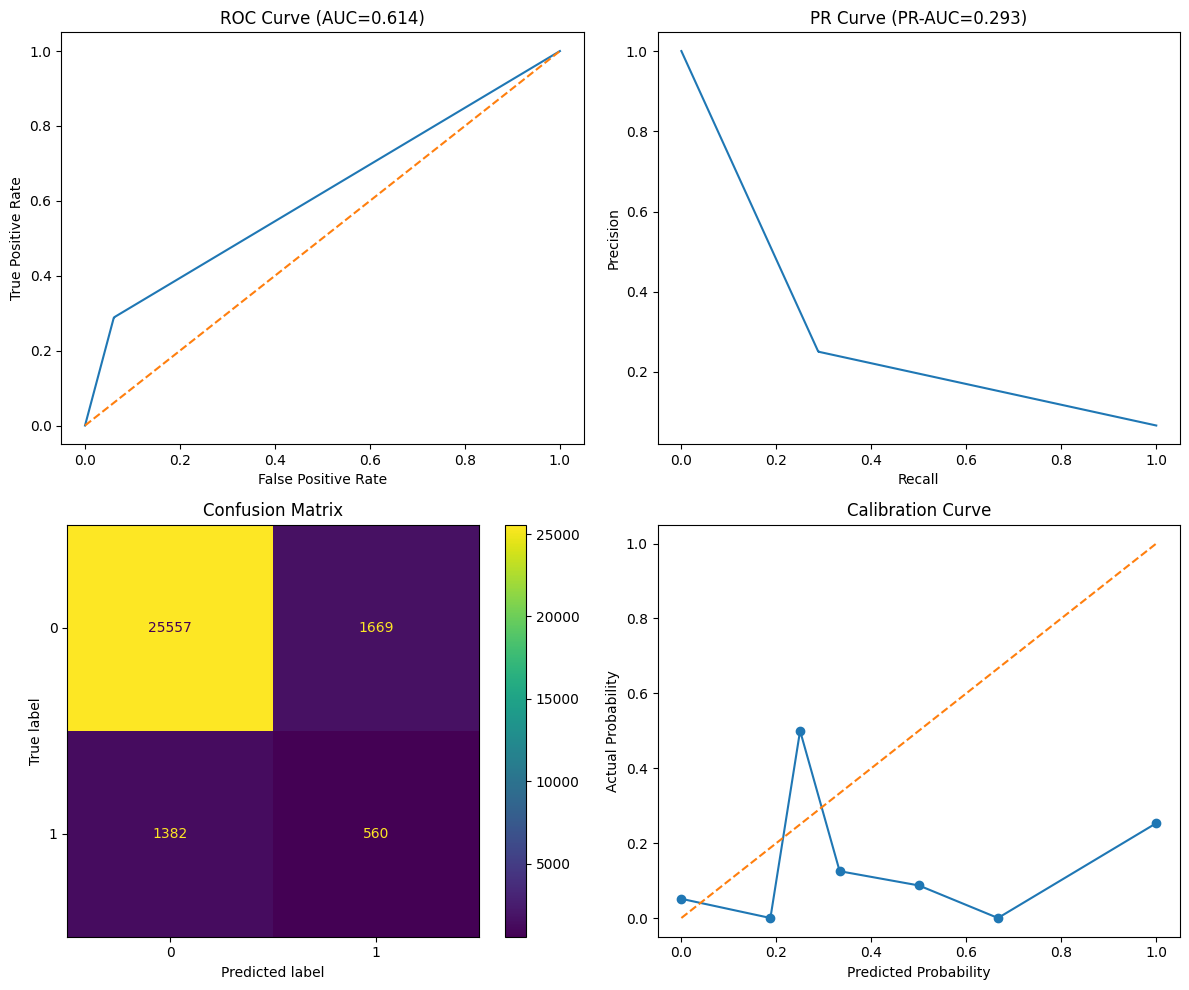

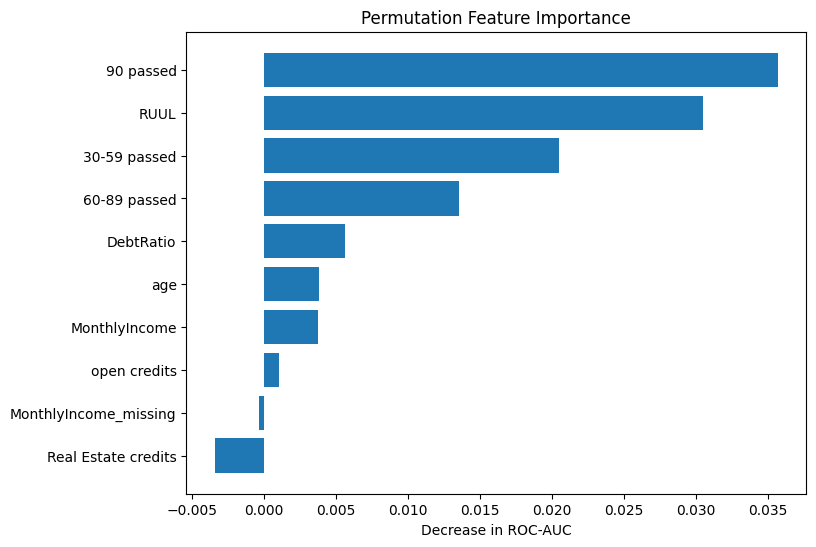

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx
Training Random Forest


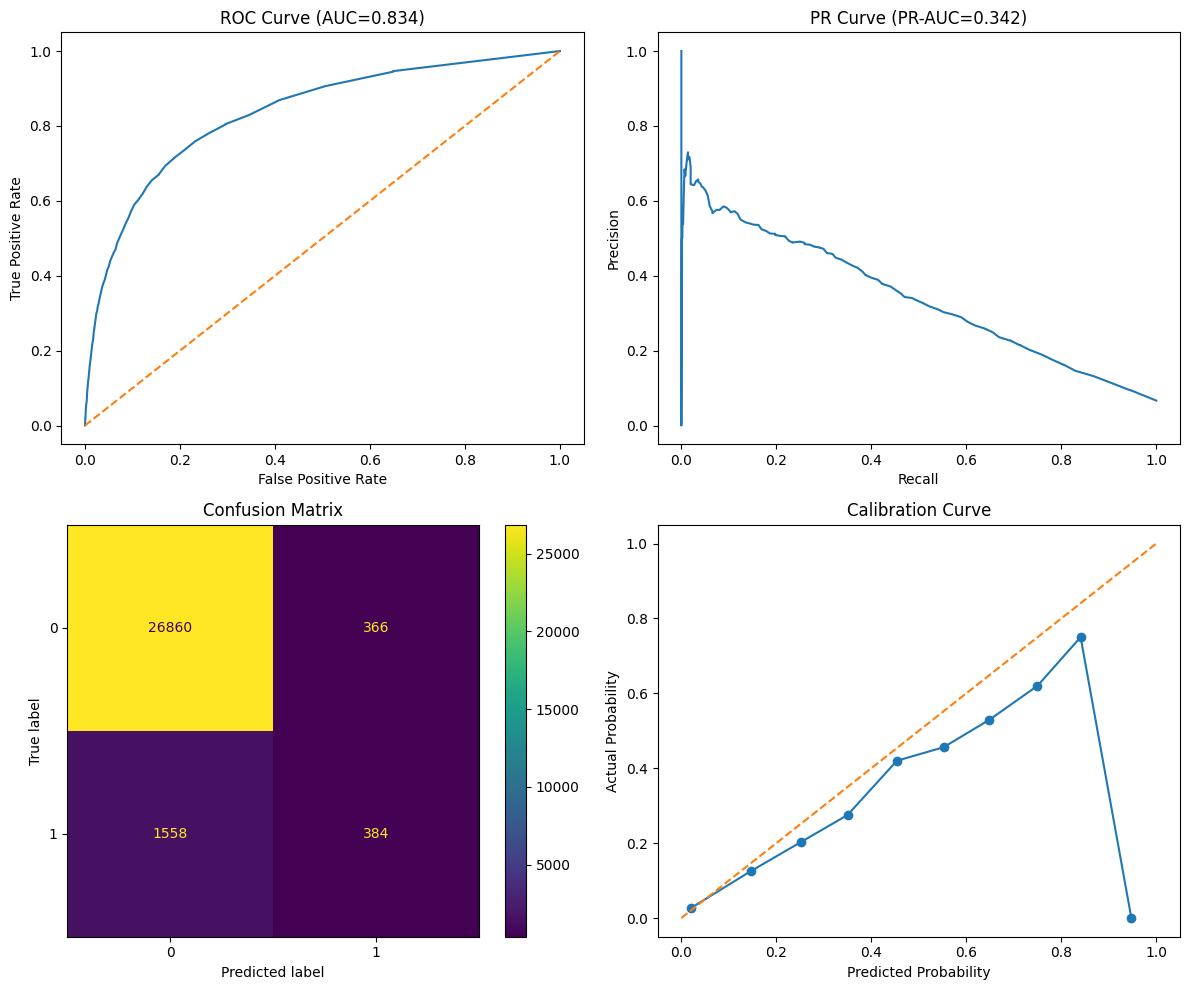

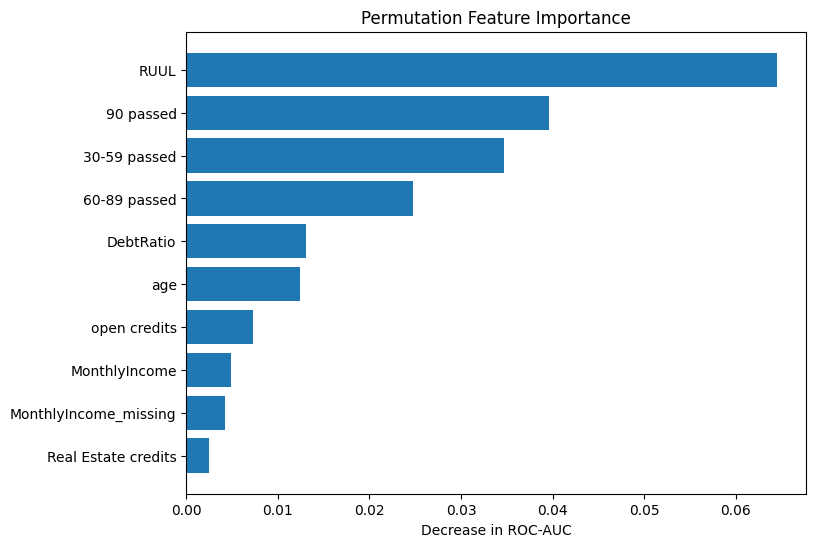

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx
Training XGBoost


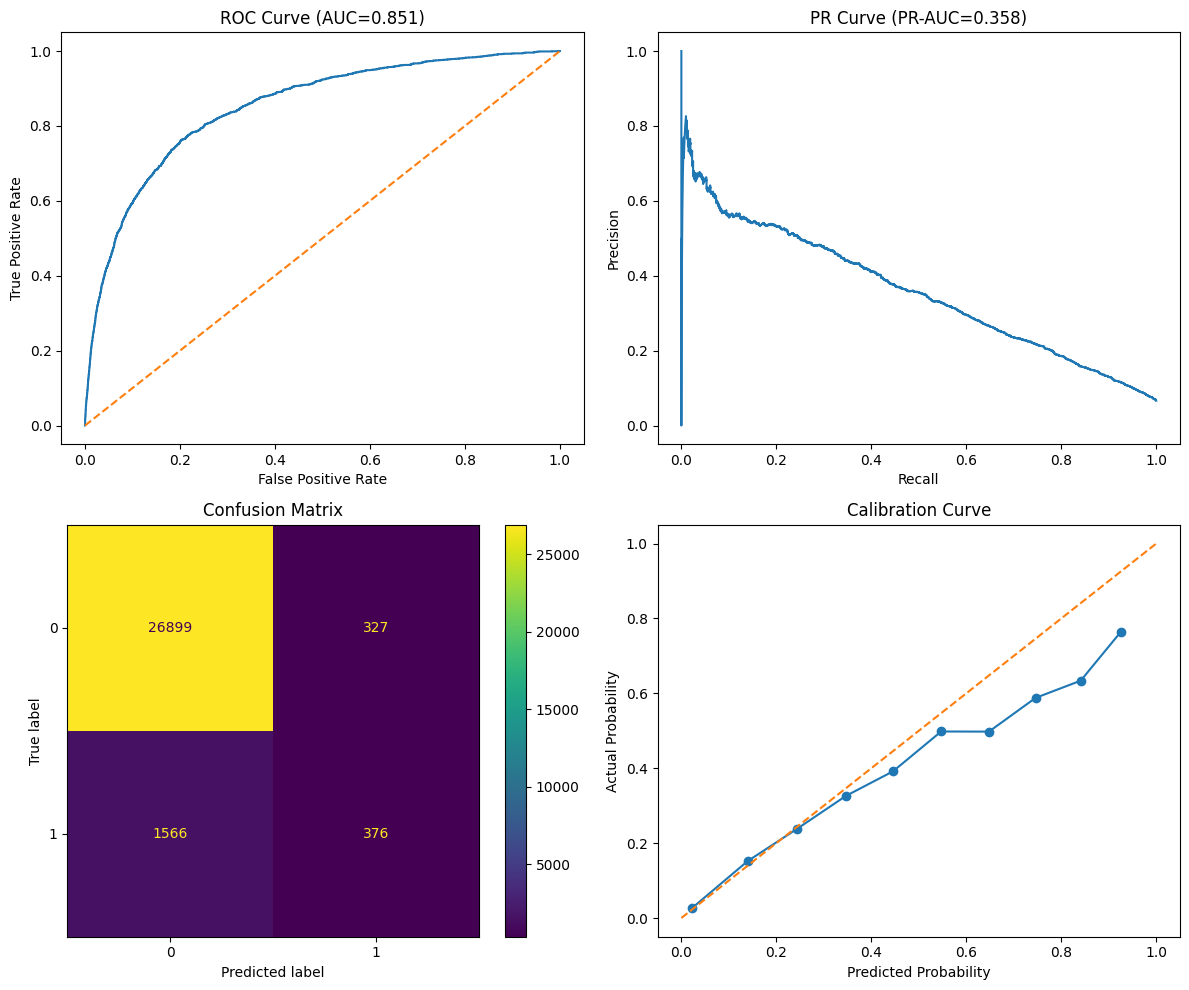

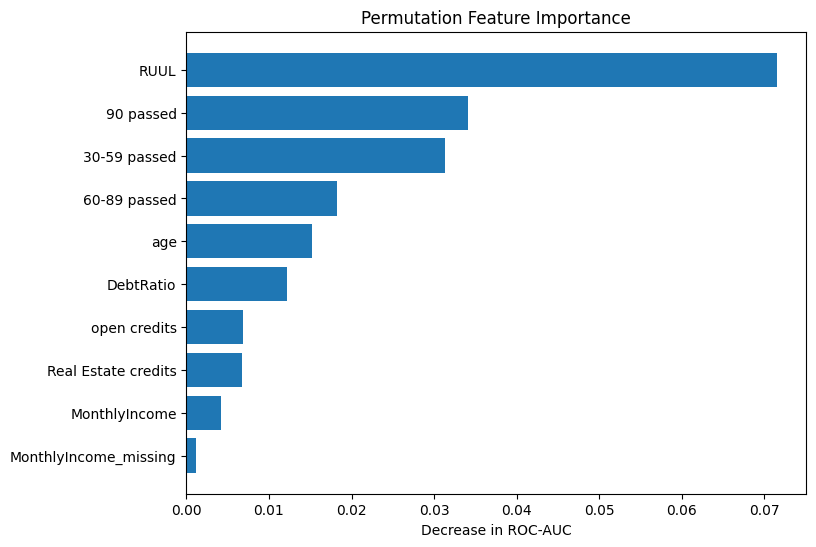

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx


In [ ]:
all_results = []
feature_importance_df = pd.DataFrame()
all_results_df = pd.DataFrame()

for name, model in base_models.items():

    print(f"Training {name}")

    model.fit(X_train_preprocessed, y_train)

    metrics, feature_importance = evaluate_model(
        model=model,
        X_train=X_train_preprocessed,
        y_train=y_train,
        X_test=X_test_preprocessed,
        y_test=y_test
)

    save_results_to_excel(
        metrics_df=metrics,
        dataset_name="Aus_Credit",
        model_name=f"Base_{name}",
        params=model.get_params(),
        comments="baseline model with Feature Selection",
        file_path = '/content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx'
)


    metrics = metrics.rename(columns={"Model_Evaluation":name})

    all_results_df = pd.concat([all_results_df,metrics],axis=1)

    renamed = {}
    for col in feature_importance.columns:
      renamed[col] = f"{name}_{col}"

    feature_importance = feature_importance.rename(columns=renamed)

    feature_importance_df = pd.concat([feature_importance_df,feature_importance],axis=1)


In [ ]:
KNN = KNeighborsClassifier()

In [ ]:
KNN.fit(X_train_preprocessed, y_train)

Knn_metrics, knn_feature_importance = evaluate_model(
        model=KNN,
        X_train=X_train_preprocessed,
        y_train=y_train,
        X_test=X_test_preprocessed,
        y_test=y_test
)

In [ ]:
SVM = SVC(kernel='linear',probability=True)

SVM.fit(X_train_preprocessed, y_train)

SVM_metrics, SVM_feature_importance = evaluate_model(
        model=SVM,
        X_train=X_train_preprocessed,
        y_train=y_train,
        X_test=X_test_preprocessed,
        y_test=y_test
)

In [ ]:
Knn_metrics = Knn_metrics.rename(columns={"Model_Evaluation":"KNN"})
SVM_metrics = SVM_metrics.rename(columns={"Model_Evaluation":"SVM"})
all_results_df = pd.concat([all_results_df,Knn_metrics,SVM_metrics],axis=1)



In [ ]:
renamed = {}
for col in SVM_feature_importance.columns:
  renamed[col] = f"{name}_{col}"

  SVM_feature_importance = SVM_feature_importance.rename(columns=renamed)

  feature_importance_df = pd.concat([feature_importance_df,SVM_feature_importance],axis=1)


In [ ]:
# all_results_df.to_excel("/content/drive/MyDrive/credit_score_project/evaluation/gmsc_base_models.xlsx")
# feature_importance_df.to_excel("/content/drive/MyDrive/credit_score_project/evaluation/gmsc_base_models_FIMP.xlsx")

In [ ]:
all_results_df

# Optuna

In [ ]:
 !pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.3 MB/s eta 0:00:00


In [ ]:
import optuna
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def get_model(trial, model_name):

  if model_name == "logistic":

    solver = trial.suggest_categorical(
        "solver", ["saga", "liblinear", "lbfgs", "newton-cg"]
    )

    C = trial.suggest_float("C", 1e-2, 1e2, log=True)

    class_weight = trial.suggest_categorical(
        "class_weight", ["balanced", None]
    )

    if solver == "saga":

        penalty = "elasticnet"

        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

    elif solver == "liblinear":

        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
        l1_ratio = None

    elif solver in ["lbfgs", "newton-cg"]:

        penalty = "l2"
        l1_ratio = None

    model = LogisticRegression(
            solver=solver,
            penalty=penalty,
            C=C,
            l1_ratio=l1_ratio,
            class_weight=class_weight,
            max_iter=1000
        )

  elif model_name == "svm":

    kernel = trial.suggest_categorical("kernel", ["linear"])

    # Common parameter
    C = trial.suggest_float("C", 1e-3, 1e3, log=True)

    if kernel == "rbf":

        gamma = trial.suggest_float("gamma", 1e-4, 1, log=True)

    else:
        gamma = "scale"

    model = SVC(
            kernel=kernel,
            C=C,
            gamma=gamma,
            probability=True
        )


  elif model_name == "knn":

        n_neighbors = trial.suggest_int("n_neighbors", 3, 50)
        leaf_size = trial.suggest_int("leaf_size", 5, 50)
        weights = trial.suggest_categorical("weights", ["uniform", "distance"])
        p = trial.suggest_categorical("p", [1, 2])


        model = KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights=weights,
                p=p,
                leaf_size = leaf_size
            )


  elif model_name == "decision_tree":

        max_depth = trial.suggest_int("max_depth", 3, 30)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
        criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

        model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            criterion=criterion
        )


  elif model_name == "random_forest":

        n_estimators = trial.suggest_int("n_estimators", 50, 400)
        max_depth = trial.suggest_int("max_depth", 5, 25)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
        bootstrap = trial.suggest_categorical("bootstrap", [True, False])
        class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=min_samples_split,
            max_features=max_features,
            bootstrap=bootstrap,
            class_weight=class_weight,
            n_jobs=-1
        )


  elif model_name == "xgboost":

    n_estimators = trial.suggest_int("n_estimators", 100, 500)

    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)

    max_depth = trial.suggest_int("max_depth", 4, 12)

    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)

    subsample = trial.suggest_float("subsample", 0.6, 1.0)

    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)

    gamma = trial.suggest_float("gamma", 0.0, 5.0)

    reg_alpha = trial.suggest_float("reg_alpha", 1e-3, 10, log=True)

    reg_lambda = trial.suggest_float("reg_lambda", 1e-3, 10, log=True)

    scale_pos_weight = trial.suggest_categorical(
        "scale_pos_weight", [1, 2, 3, 5]
    )

    model = XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        use_label_encoder=False,
        n_jobs=-1
    )

  else:
      raise ValueError("Invalid model name")

  return model

In [ ]:
def objective(trial, model_name, X_train, y_train):

    model = get_model(trial, model_name)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score

In [ ]:
def tune_model(model_name, X_train, y_train, n_trials=30):

    study = optuna.create_study(direction="maximize")

    study.optimize(
        lambda trial: objective(trial, model_name, X_train, y_train),
        n_trials=n_trials
    )

    return study

In [ ]:
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_contour,
    plot_slice
)


def plot_optuna_diagnostics(study, plots=None):
    """
    Plots key Optuna diagnostic graphs.

    Parameters:
    ----------
    study : optuna.study.Study
        Completed Optuna study

    plots : list (optional)
        List of plots to generate. Options:
        ["history", "importance", "parallel", "contour", "slice"]
        Default = all
    """

    if plots is None:
        plots = ["history", "importance", "parallel", "contour", "slice"]

    print("\n📊 Optuna Study Diagnostics\n")

    # 1. Optimization History
    if "history" in plots:
        print("▶ Optimization History")
        fig = plot_optimization_history(study)
        fig.show()

    # 2. Parameter Importance
    if "importance" in plots:
        print("▶ Parameter Importance")
        fig = plot_param_importances(study)
        fig.show()

    # 3. Parallel Coordinate Plot
    if "parallel" in plots:
        print("▶ Parallel Coordinate Plot")
        fig = plot_parallel_coordinate(study)
        fig.show()

    # 4. Contour Plot (interaction between params)
    if "contour" in plots:
        print("▶ Contour Plot")
        fig = plot_contour(study)
        fig.show()

    # 5. Slice Plot (individual param vs objective)
    if "slice" in plots:
        print("▶ Slice Plot")
        fig = plot_slice(study)
        fig.show()

In [ ]:
study1 = tune_model('logistic', X_train_preprocessed, y_train, n_trials=100)

[I 2026-03-30 10:25:54,257] A new study created in memory with name: no-name-820f7f0e-bd52-4d57-85f6-9b225d42bcfa
[I 2026-03-30 10:25:57,174] Trial 0 finished with value: 0.6997756262817934 and parameters: {'solver': 'newton-cg', 'C': 6.475346212299438, 'class_weight': None}. Best is trial 0 with value: 0.6997756262817934.
[I 2026-03-30 10:25:57,215] Trial 1 finished with value: 0.6916288118375405 and parameters: {'solver': 'liblinear', 'C': 0.16646572503631124, 'class_weight': None, 'penalty': 'l1'}. Best is trial 0 with value: 0.6997756262817934.
[I 2026-03-30 10:25:57,266] Trial 2 finished with value: 0.702613780116152 and parameters: {'solver': 'saga', 'C': 0.38166394818650945, 'class_weight': 'balanced', 'l1_ratio': 0.561863130045468}. Best is trial 2 with value: 0.702613780116152.
[I 2026-03-30 10:25:57,316] Trial 3 finished with value: 0.6372882046269143 and parameters: {'solver': 'saga', 'C': 0.0169481027862512, 'class_weight': 'balanced', 'l1_ratio': 0.9112200925567897}. Best 

In [ ]:
print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

plot_optuna_diagnostics(study)

Best Score: 0.7033269123876335
Best Params: {'solver': 'saga', 'C': 0.4785700427016291, 'class_weight': 'balanced', 'l1_ratio': 0.2132837811605799}

📊 Optuna Study Diagnostics

▶ Optimization History


▶ Parameter Importance


[W 2026-03-30 10:32:52,676] Your study has only completed trials with missing parameters.


▶ Parallel Coordinate Plot


▶ Contour Plot


/tmp/ipykernel_9417/2675857356.py:52: UserWarning:

Contour plot will not be displayed because `l1_ratio` and `penalty` cannot co-exist in `trial.params`.

/tmp/ipykernel_9417/2675857356.py:52: UserWarning:

Contour plot will not be displayed because `penalty` and `l1_ratio` cannot co-exist in `trial.params`.



▶ Slice Plot


In [ ]:
hgcjgcjgcnb jb jbjbob
hello there do not die out there
jhvi
jvhv
 ioln
 stfxtf
 uhgjh
 hgcfdx
 jvjvih

In [ ]:
models = [
    # "logistic",
    #  "svm",
    #  "knn"
    # "decision_tree"
     "random_forest"
    #  "xgboost"
]

all_studies = {}

for model_name in models:

    print(f"\nTuning {model_name}...")

    study = tune_model(model_name, X_train_preprocessed, y_train, n_trials=50)

    all_studies[model_name] = study

    print("Best Score:", study.best_value)
    print("Best Params:", study.best_params)
    plot_optuna_diagnostics(study)

[I 2026-04-03 18:09:47,897] A new study created in memory with name: no-name-ac2d1246-c93b-412c-ae9f-68dda8f92c77



Tuning random_forest...


[I 2026-04-03 18:13:55,591] Trial 0 finished with value: 0.854212782440055 and parameters: {'n_estimators': 309, 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 6, 'max_features': None, 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.854212782440055.
[I 2026-04-03 18:16:00,183] Trial 1 finished with value: 0.8599191866010049 and parameters: {'n_estimators': 332, 'max_depth': 10, 'min_samples_leaf': 15, 'min_samples_split': 18, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8599191866010049.
[I 2026-04-03 18:18:10,399] Trial 2 finished with value: 0.8429558448649358 and parameters: {'n_estimators': 85, 'max_depth': 20, 'min_samples_leaf': 7, 'min_samples_split': 7, 'max_features': None, 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8599191866010049.
[I 2026-04-03 18:19:12,911] Trial 3 finished with value: 0.8571940961031871 and parameters: {'n_estimators': 295

Best Score: 0.8624775873866782
Best Params: {'n_estimators': 239, 'max_depth': 12, 'min_samples_leaf': 17, 'min_samples_split': 16, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}

📊 Optuna Study Diagnostics

▶ Optimization History


▶ Parameter Importance


▶ Parallel Coordinate Plot


▶ Contour Plot


▶ Slice Plot


In [ ]:
# rebuild model
best_model.fit(X_train, y_train)

In [ ]:
all_studies['xgboost'].best_params


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:06:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




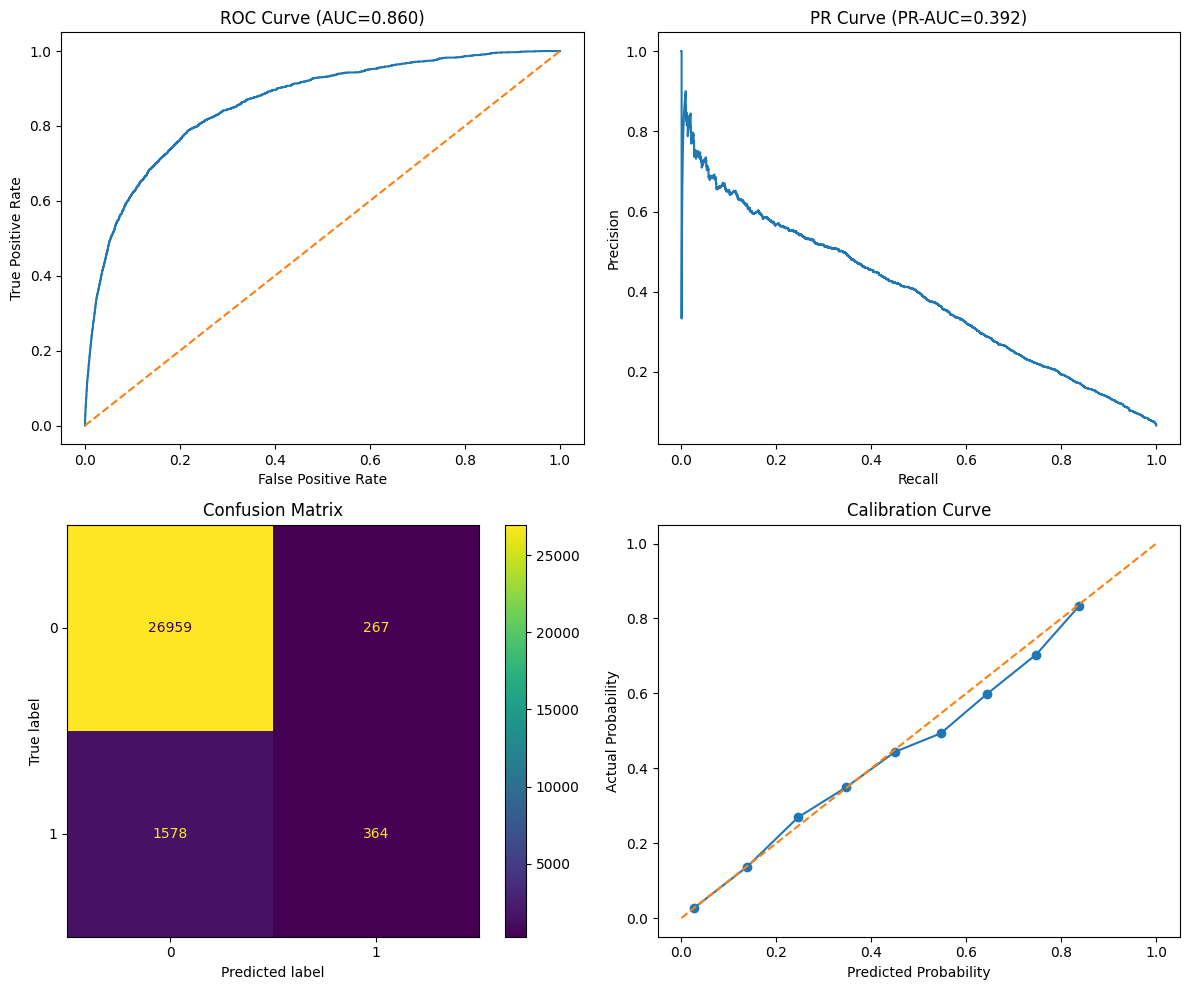

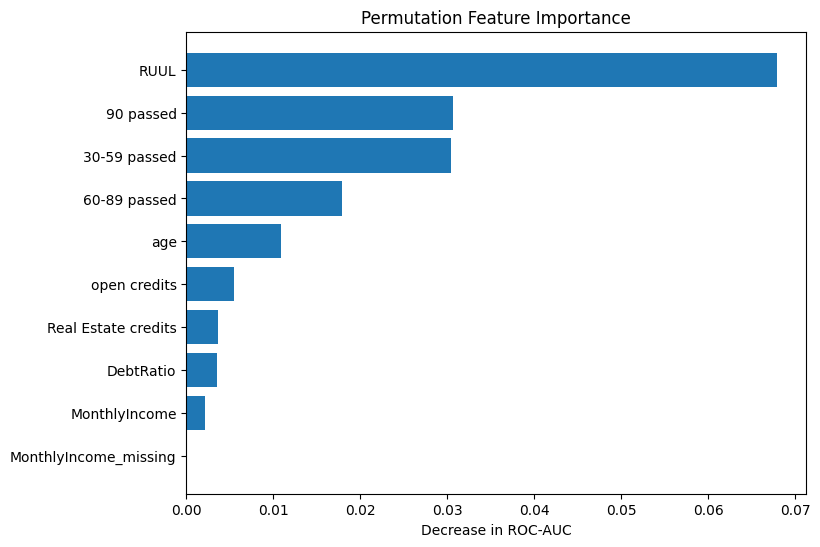

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx


In [ ]:
models = [
    # "logistic",
    # "svm",
    #  "knn"
    # "decision_tree"
    #  "random_forest"
     "xgboost"
]

for model_name in models:
  best_params = all_studies[model_name].best_params
  trial = optuna.trial.FixedTrial(best_params)
  best_model = get_model(trial, model_name)

  best_model.fit(X_train_preprocessed, y_train)

  metrics, feature_importance = evaluate_model(
          model=best_model,
          X_train=X_train_preprocessed,
          y_train=y_train,
          X_test=X_test_preprocessed,
          y_test=y_test
      )

  save_results_to_excel(
        metrics_df=metrics,
        dataset_name="GMSC_Credit",
        model_name=f"HPT_{model_name}",
        params=best_model.get_params(),
        comments="Tunned model",
        file_path = '/content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx'
)